# Import libraries

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from helpers.grid import deme_id, decode_deme, create_grid
from helpers.tree import simulate_tree, drop_mutations, get_descendants, build_ancestral_genotype
from helpers.vizualisation import map_to_color, vizualise_pops

# Parameters

In [2]:
# Cell 2 — Parameters
k                = 10      # k×k grid
Ne               = 500    # effective size per deme (sets coalescence rate)
M                = 0.5    # migration rate (number of migrants per generation)
n_per_deme       = 20      # haploid samples per deme
n_loci           = 100    # independent loci to simulate
n_mutations      = 1      # mutations to drop per locus
random_seed      = 42

rng = np.random.default_rng(random_seed)

n_demes     = k * k
n_samples   = n_demes * n_per_deme   # total haplotypes

# Create grid

In [3]:
grid, neighbors = create_grid(k)

In [4]:
print(grid)
print(f"\nCorners=2, edges=3, interior=4 ✓" if grid[0,0]==2 else "⚠ check neighbor logic")

[[2 3 3 3 3 3 3 3 3 2]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [2 3 3 3 3 3 3 3 3 2]]

Corners=2, edges=3, interior=4 ✓


In [5]:
# Cell 6 — Run n_loci Simulations and Build Genotype Matrix
G = build_ancestral_genotype(n_loci, k, n_per_deme, Ne, M, neighbors, rng, n_mutations)
print(f"Simulating {n_loci} loci on a {k}×{k} grid...")

print(f"\n✓ Done!")
print(f"Genotype matrix : {G.shape}  (variants × haplotypes)")
print(f"Mean AF         : {G.mean():.4f}")

# Deme label for each haplotype column
sample_demes = np.repeat(np.arange(n_demes), n_per_deme)
print(f"Sample demes    : {sample_demes[:10]}...")

  locus 0/100...
  locus 50/100...
Simulating 100 loci on a 10×10 grid...

✓ Done!
Genotype matrix : (100, 2000)  (variants × haplotypes)
Mean AF         : 0.1307
Sample demes    : [0 0 0 0 0 0 0 0 0 0]...


In [6]:
# ── Standardize and run PCA ──
G_f    = G.T.astype(float)
std    = G_f.std(axis=0); std[std == 0] = 1
G_std  = (G_f - G_f.mean(axis=0)) / std
pca    = PCA(n_components=2)
coords = pca.fit_transform(G_std)


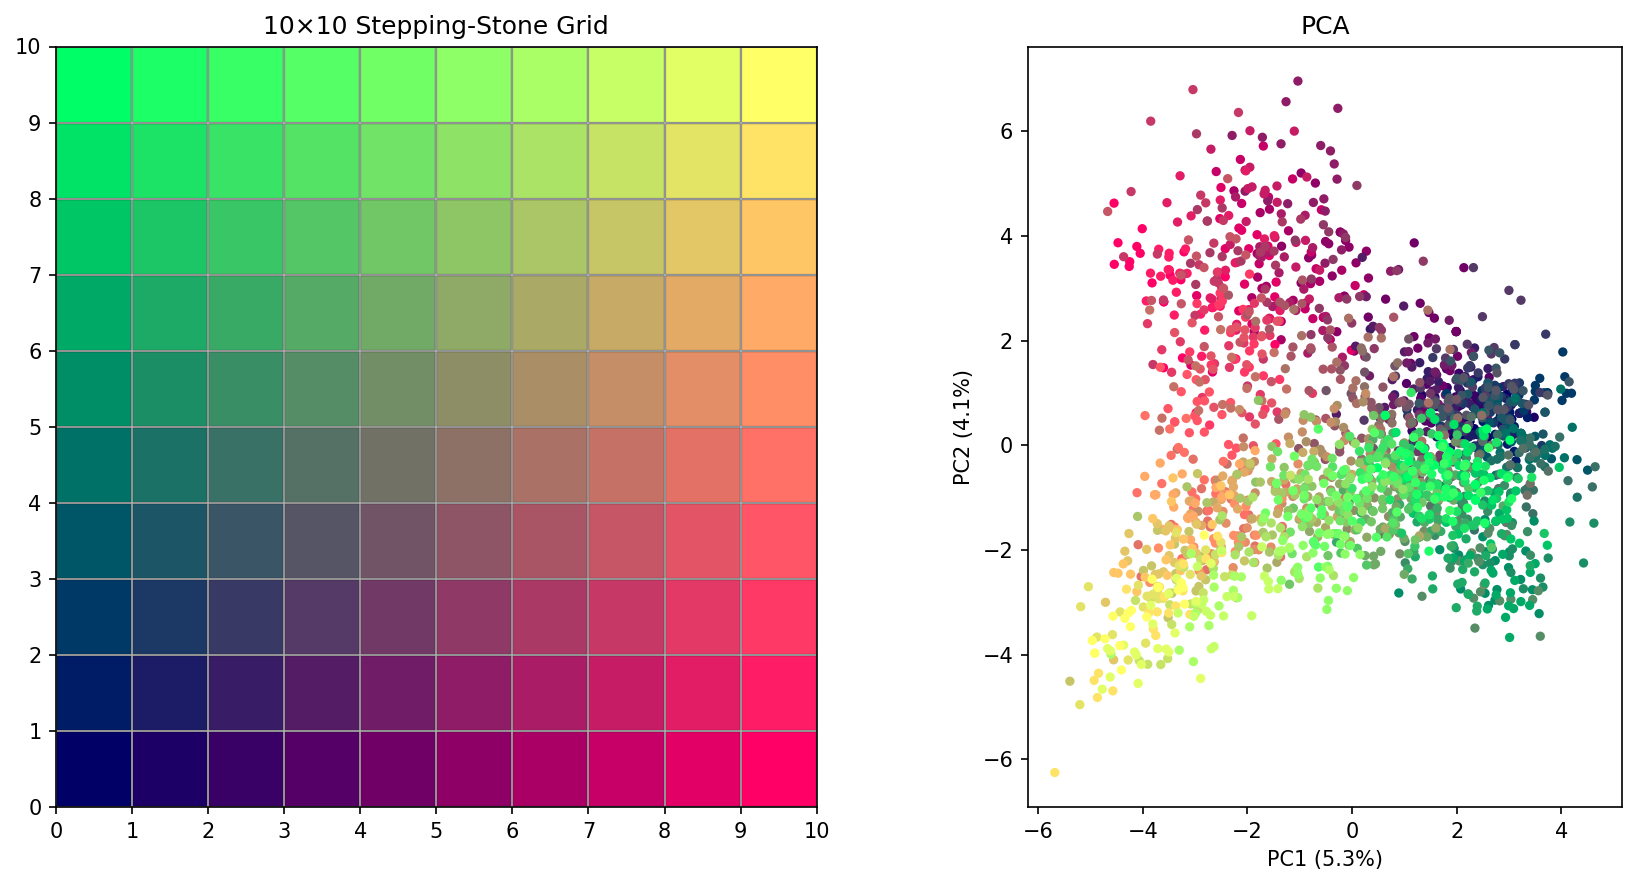

In [7]:
vizualise_pops(n_demes, n_per_deme, k, pca, coords)

# From ancestral to current

In [8]:
G

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(100, 2000), dtype=int8)